# Exploration phase for developing the model

## 1. Imports

In [1]:
import os
from dotenv import load_dotenv
import pyarrow
from pathlib import Path
import boto3
import pandas as pd
import numpy as np

In [2]:
load_dotenv()
os.getenv('AWS_ACCESS_KEY_ID') is not None

True

## 2. Data set loading

In [3]:
s3 = boto3.client('s3')

BUCKET = 'zrive-ds-data'
PREFIX = 'groceries/box_builder_dataset/'

response = s3.list_objects_v2(
    Bucket = BUCKET,
    Prefix = PREFIX
)

key = response['Contents'][0]['Key']
filename = response['Contents'][0]['Key'].split('/')[-1]

local_data_dir = Path('../../data/module3')
local_path = local_data_dir/filename

if local_path.exists():
        print(f'{filename} already exists')
else:
    print(f'Downloading: {filename}')
    s3.download_file(BUCKET,key,local_path)

feature_frame.csv already exists


In [4]:
df_original= pd.read_csv(local_path)
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Data columns (total 27 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   variant_id                        int64  
 1   product_type                      object 
 2   order_id                          int64  
 3   user_id                           int64  
 4   created_at                        object 
 5   order_date                        object 
 6   user_order_seq                    int64  
 7   outcome                           float64
 8   ordered_before                    float64
 9   abandoned_before                  float64
 10  active_snoozed                    float64
 11  set_as_regular                    float64
 12  normalised_price                  float64
 13  discount_pct                      float64
 14  vendor                            object 
 15  global_popularity                 float64
 16  count_adults                      fl

In [5]:
df_original.head()

,variant_id,product_type,order_id,user_id,created_at,order_date,user_order_seq,outcome,ordered_before,abandoned_before,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
0,33826472919172,ricepastapulses,2807985930372,3482464092292,2020-10-05 16:46:19,2020-10-05 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
1,33826472919172,ricepastapulses,2808027644036,3466586718340,2020-10-05 17:59:51,2020-10-05 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
2,33826472919172,ricepastapulses,2808099078276,3481384026244,2020-10-05 20:08:53,2020-10-05 00:00:00,4,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
3,33826472919172,ricepastapulses,2808393957508,3291363377284,2020-10-06 08:57:59,2020-10-06 00:00:00,2,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618
4,33826472919172,ricepastapulses,2808429314180,3537167515780,2020-10-06 10:37:05,2020-10-06 00:00:00,3,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,33.0,42.0,31.134053,30.0,30.0,24.27618


In [6]:
df_original['vendor'].nunique()

264

In [7]:
df_original['product_type'].nunique()

62

## 3. Data Set cleaning

In [8]:
df = df_original.copy()

### Orders with at least 5 products

In [9]:
df_order_size = df.groupby("order_id")['variant_id'].count().reset_index(name="n_products")
df_order_size.head()

,order_id,n_products
0,2807985930372,608
1,2808027644036,608
2,2808099078276,608
3,2808393957508,611
4,2808429314180,614


In [10]:
(df_order_size['n_products']<5).sum()

0

We find that there are no order_ids with smaller number of items than 5, therefore we do not have to eliminate any order_id from the initial data set, once this is done, order_id can be droped for model training, as it doesn't contain predictive power.

### Variables with date information to date time

This may be useful for be able to split the data into day, month and hour, so the model can learn from it. Also for later scaling, because as strings, scaler will fail

In [11]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['order_hour'] = df['created_at'].dt.hour
df['order_month'] = df['created_at'].dt.month
df['order_dayweek'] = df['created_at'].dt.dayofweek

The variables created at and order_date will be removed from the feature selection, as their information is contained in this columns

### One-hot encoding of categorical variables 

The string columns that we have to encode are vendor and product_type. As we saw in the first part, they have 62 and 324 values, what will generate 386 new columns, not exagerated for our model.

In [12]:
df = pd.get_dummies(df, columns=["product_type","vendor"])

## Model selection and evaluation

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import RidgeClassifier

### Data split and scale

We will remove variant_id, order_id and user_id as well as the variables encoded and tranformed into datetime.
- order id was only used for filtering
- variant_id and user_id are integers, so the model would assign coefficients to them as if they were numerical variables, what makes no sense, and hot-encoding them would generate an extreme number of extra-columns.
- Must be also taken into account that information regarding user_id and variant_id is already contained in the rest of the columns, such as user_order_seq, ordered_before, or avs_days_to_buy_variant_id.
- So, i think that the aim of the model is to develop a probability trasformed then into 1-0 based on a threshold for each line of the data set, that can be then related to a (user,variant_id) by another level of the process that uses the whole dataset.

In [14]:
X = df.drop(columns = [
    'outcome',
    'order_id',
    'created_at',
    'order_date',
    'user_id',
    'variant_id'
])
y = df['outcome']

In [15]:
X_temp,X_test,y_temp,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

X_train,X_val,y_train,y_val = train_test_split(
    X_temp,
    y_temp,
    test_size = 0.25,
    random_state = 42,
    stratify = y_temp
)



In [16]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2880549 entries, 0 to 2880548
Columns: 348 entries, user_order_seq to vendor_zoflora
dtypes: bool(326), float64(18), int32(3), int64(1)
memory usage: 1.3 GB


In [17]:
num_cols = X_train.select_dtypes(include=["int","float"]).columns

In [18]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


Why do we scale?
- Because in classificaton, models like LogisticRegression minimize their loss function using gradient descent. If we do not normalize the variables and some have very different scales, the model may not converge or spend more time and iterations to do so.
- Furthermore, when using penalizations as L1 or L2, as we will, if some variables have dioferent scales, the model might penalize hard the coefficient of the variable with a higer scale just to compensate the high number it is multiplying, making it seem less important when it may not be so. 

Why do we make only .fit on train?
- Because when we make .fit to the scaler, it learns the mean and std of the features.
- If we apply .fit also to validation and test, the model will then have access to this information when training it on the scaled splits, resulting in data leakage

### Model training

When training the model, I found that my computer had not enough memory, so I tried to solve it in the following way:
- Tranform the numerical variables from 64 bits to 32
- Use SGDClassifier instead of Logistics regressor and SGDClassifier with l2 penalization instead of RidgeRegressor. This is beacuse SGDClassifier uses Stochastics gradient descent to minimize the loss function, updating the coefficients using onle small portions of the data set at a time, reducing the use of memory. This is just an aproxiamtion to the RidgeClassifier as the loss function is not the same, but it was the only solution I found

In [19]:
num_cols = X_train.select_dtypes(include=["float"]).columns

X_train[num_cols] = X_train[num_cols].astype("float32")
X_val[num_cols] = X_val[num_cols].astype("float32")
X_test[num_cols] = X_test[num_cols].astype("float32")

In [20]:
sample_size = 200000

sample_idx = X_train.sample(sample_size, random_state=42).index

X_train_sample = X_train.loc[sample_idx]
y_train_sample = y_train.loc[sample_idx]

In [21]:
log_model = SGDClassifier(
    loss="log_loss",
    max_iter=1000
)

log_model.fit(X_train_sample, y_train_sample)

SGDClassifier(loss='log_loss')

The limit for the memory of my computer is 200k samples, with 250k the kernel stops and die

In [22]:
log_l1_model = SGDClassifier(
    loss="log_loss",
    penalty="l1",
    max_iter=1000
)

log_l1_model.fit(X_train_sample, y_train_sample)

SGDClassifier(loss='log_loss', penalty='l1')

In [23]:
log_l2_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    max_iter=1000
)

log_l2_model.fit(X_train_sample, y_train_sample)

SGDClassifier(loss='log_loss')

### Hyperparameter tuning

We will use the area under the curve PR as a metric for finding the best value for the hyperparameter, as it is said in the problem decription that precisin is very important,because if we lower it, churn cost is very high.

If we AUC PR is higher, we will be able to achieve a higher valur of precision without sacrifying a los of recall

In [24]:
from sklearn.metrics import precision_recall_curve,auc


In [25]:
val_sample_idx = X_val.sample(sample_size, random_state=42).index

X_val_sample = X_val.loc[val_sample_idx]
y_val_sample = y_val.loc[val_sample_idx]

In [26]:
alphas = [1e-5, 1e-4, 1e-3, 1e-2]

In [27]:
results_l1 = []

for alpha in alphas:
    log_l1_model = SGDClassifier(
    loss="log_loss",
    penalty="l1",
    alpha = alpha,
    random_state = 42,
    max_iter=1000
)
    log_l1_model.fit(X_train_sample, y_train_sample)

    y_val_prob = log_l1_model.predict_proba(X_val_sample)[:,1]
    precision,recall,_ = precision_recall_curve(y_val_sample,y_val_prob)

    pr_auc = auc(recall,precision)

    results_l1.append((alpha,pr_auc))

print(results_l1)




[(1e-05, 0.11899897647441975), (0.0001, 0.15297584093177755), (0.001, 0.15912185373026727), (0.01, 0.1551020416559373)]


In [28]:
results_l2 = []

for alpha in alphas:
    log_l2_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha = alpha,
    random_state = 42,
    max_iter=1000
)
    log_l2_model.fit(X_train_sample, y_train_sample)

    y_val_prob = log_l2_model.predict_proba(X_val_sample)[:,1]
    precision,recall,_ = precision_recall_curve(y_val_sample,y_val_prob)

    pr_auc = auc(recall,precision)

    results_l2.append((alpha,pr_auc))

print(results_l2)


[(1e-05, 0.14691714118991728), (0.0001, 0.16628105334194146), (0.001, 0.17294636759337714), (0.01, 0.16880596060021283)]


In [29]:
results_log = []

for alpha in alphas:
    log_model = SGDClassifier(
    loss="log_loss",
    penalty=None,
    alpha = alpha,
    random_state = 42,
    max_iter=1000
)
    log_model.fit(X_train_sample, y_train_sample)

    y_val_prob = log_model.predict_proba(X_val_sample)[:,1]
    precision,recall,_ = precision_recall_curve(y_val_sample,y_val_prob)

    pr_auc = auc(recall,precision)

    results_log.append((alpha,pr_auc))

print(results_log)

[(1e-05, 0.14085009171215368), (0.0001, 0.15121757687185206), (0.001, 0.09303230598347324), (0.01, 0.10733612172767044)]


### Final model test

As saw in validation, the best model is the SGDClassifier with l2 penalization and an alpha = 0.001

In [30]:
best_alpha = 0.001

final_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha = best_alpha,
    random_state = 42,
    max_iter=1000
)

half = sample_size // 2 # I can not used pd.concat as it will create a DF of 3.4M rows, and my ram can not handle it
train_idx = X_train.sample(half, random_state=42).index

X_train_part = X_train.loc[train_idx]
y_train_part = y_train.loc[train_idx]

val_idx = X_val.sample(half, random_state=42).index

X_val_part = X_val.loc[val_idx]
y_val_part = y_val.loc[val_idx]

X_train_val_sample = pd.concat([X_train_part, X_val_part])
y_train_val_sample = pd.concat([y_train_part, y_val_part])

test_sample_idx = X_test.sample(sample_size, random_state = 42).index
X_test_sample = X_test.loc[test_sample_idx]
y_test_sample = y_test.loc[test_sample_idx]

final_model.fit(X_train_val_sample, y_train_val_sample)


y_test_prob = final_model.predict_proba(X_test_sample)[:,1]

precision, recall, _ = precision_recall_curve(y_test_sample, y_test_prob)
pr_auc_test = auc(recall, precision)

print(pr_auc_test)

0.17235050176851832


<function matplotlib.pyplot.show(close=None, block=None)>

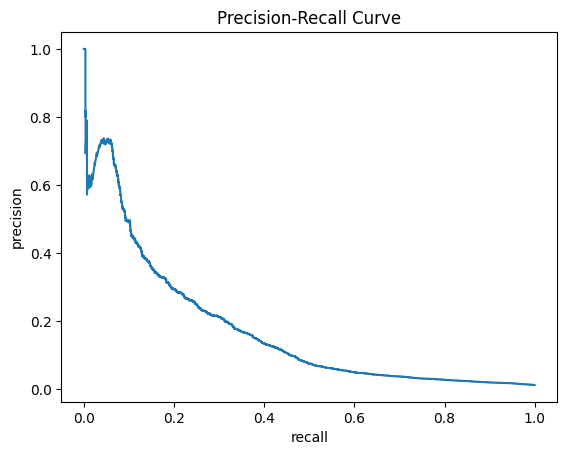

In [32]:
import matplotlib.pyplot as plt

precision,recall,thresholds = precision_recall_curve(y_test_sample,y_test_prob)

plt.figure()
plt.plot(recall,precision)
plt.xlabel('recall')
plt.ylabel('precision')
plt.title('Precision-Recall Curve')
plt.show

Rather than choosing a threshold, that doesnt allow us to select to how many users do we want to send push notifications (something very important as churn has been said to have a very high cost), something that may help more the business is to determine the % of precision if we target the top x% users.

That is, if select the top x% probabilities of buying, how many are we getting right? Instead of choosing an arbitrary threshold, we choose the number of users we want to target, with the knowledge of the precision we will have.

With that said, it is true that if we follow this strategy we do not look at the recall weget. That is, we migh target the 5% users, obtain a60% of precision, but having a very low recall. This is a question that we should ask the business: 
- How much do you preffer precision over recall?

However, a solution to this, and to offer a more broad view of the situation, is to compute the precision when targeting the X top percent, but also the recall. That way the business can take a decision knowing how many sellers they are not targeting, when accepting to send push notification only to a determine %.

In [33]:
import numpy as np

k_values = [0.05, 0.10, 0.15, 0.20]

results = []

for k_pct in k_values:
    
    k = int(len(y_test_prob) * k_pct)
    
    # índices del top k%
    idx = np.argsort(y_test_prob)[-k:]
    
    # precision@k
    precision_k = y_test_sample.iloc[idx].mean()
    
    # recall@k
    recall_k = y_test_sample.iloc[idx].sum() / y_test_sample.sum()
    
    results.append((k_pct, precision_k, recall_k))

for r in results:
    print(f"Top {int(r[0]*100)}% → Precision: {r[1]:.3f}, Recall: {r[2]:.3f}")

Top 5% → Precision: 0.104, Recall: 0.453
Top 10% → Precision: 0.062, Recall: 0.540
Top 15% → Precision: 0.047, Recall: 0.612
Top 20% → Precision: 0.039, Recall: 0.675


Targeting the top 5% of users ranked by predicted purchase probability yields a precision of 10.4% and captures 45% of all purchases. This more than doubles the current push notification open rate of 5%.

This suggest that a very small group of the users represent a great part of the orders made, and also that our model does relatively well in identifyting that group of users and predicting a high probability.